<a href="https://colab.research.google.com/github/alimoorreza/CS181-fall26-notes/blob/main/day13_object_detection_training_finetuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Object detection: fine-tuning a pre-trained object detection model**
- Object detection models: `Faster R-CNN`, `Mask R-CNN`
- Dataset used: [Microsoft COCO (Common Object in COntext)](https://cocodataset.org/#explore)
    - Both model has been trained on the COCO dataset and can recognize 91 objects, including `person`, `dog`, and `cat`.
    - Here, we will be fine-tuning these models using the `PennFudanPed` Dataset, which contains only one object class:`person`.

##**PenFudanPed: a pedestrian dataset**
- This dataset contains images of people walking on the streets. Our goal is to fine-tune the model to improve its ability to detect pedestrians. [https://www.cis.upenn.edu/~jshi/ped_html/PennFudanPed.zip](https://www.cis.upenn.edu/~jshi/ped_html/PennFudanPed.zip)
- I have also uploaded the dataset to Blackboard; you can download it from there as well.
- Alternatively, you can execute the following lines or manually download the dataset and upload it to your Google Drive:
  - !wget https://www.cis.upenn.edu/~jshi/ped_html/PennFudanPed.zip
  - !unzip PennFudanPed.zip

In [1]:
from google.colab import drive
drive.mount('/content/drive')

root = '/content/drive/MyDrive/cs181_fall26/module_4_detection/'

Mounted at /content/drive


In [2]:
%%shell
git clone https://github.com/alimoorreza/cs181_fall26_detection.git

cp cs181_fall26_detection/utils.py ./
cp cs181_fall26_detection/transforms.py ./
cp cs181_fall26_detection/coco_eval.py ./
cp cs181_fall26_detection/engine.py ./
cp cs181_fall26_detection/coco_utils.py ./

Cloning into 'cs181_fall26_detection'...
remote: Enumerating objects: 19, done.
remote: Counting objects: 100% (19/19), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 19 (delta 2), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (19/19), 28.84 KiB | 3.61 MiB/s, done.
Resolving deltas: 100% (2/2), done.


In [3]:
%%shell
pip install cython

In [4]:
import torch
print(torch.__version__)

2.11.0+cpu


###**Dataset Class creation**
Create a dataset class that stores the image names, a list of bounding boxes for each image, object segmentation masks, and other metadata. We will use this class to create two separate subsets:
- a training dataset
- a testing dataset


In [5]:
import os
import numpy as np
import torch
import torch.utils.data
from PIL import Image


class PennFudanDataset(torch.utils.data.Dataset):
    def __init__(self, root, transforms=None):
        self.root = root
        self.transforms = transforms
        # load all image files, sorting them to
        # ensure that they are aligned
        self.imgs = list(sorted(os.listdir(os.path.join(root, "PNGImages"))))
        self.masks = list(sorted(os.listdir(os.path.join(root, "PedMasks"))))

    def __getitem__(self, idx):
        # load images and masks
        img_path    = os.path.join(self.root, "PNGImages", self.imgs[idx])
        mask_path   = os.path.join(self.root, "PedMasks", self.masks[idx])
        img         = Image.open(img_path).convert("RGB")
        mask        = Image.open(mask_path) # note that we haven't converted the mask to RGB because each color corresponds to a different instance with 0 being background



        mask        = np.array(mask)
        obj_ids     = np.unique(mask) # instances are encoded as different colors
        obj_ids     = obj_ids[1:]     # first id is the background, so remove it

        # split the color-encoded mask into a set of binary masks
        masks       = mask == obj_ids[:, None, None]

        # get bounding box coordinates for each mask
        num_objs    = len(obj_ids)
        boxes       = []
        for i in range(num_objs):
            pos = np.where(masks[i])
            xmin = np.min(pos[1])
            xmax = np.max(pos[1])
            ymin = np.min(pos[0])
            ymax = np.max(pos[0])
            boxes.append([xmin, ymin, xmax, ymax])

        boxes       = torch.as_tensor(boxes, dtype=torch.float32)
        labels      = torch.ones((num_objs,), dtype=torch.int64) # there is only one class
        masks       = torch.as_tensor(masks, dtype=torch.uint8)

        image_id    = torch.tensor([idx])
        area        = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])
        iscrowd     = torch.zeros((num_objs,), dtype=torch.int64) # suppose all instances are not crowd

        target              = {}
        target["boxes"]     = boxes
        target["labels"]    = labels
        target["masks"]     = masks
        target["image_id"]  = image_id
        target["area"]      = area
        target["iscrowd"]   = iscrowd

        if self.transforms is not None:
            img, target = self.transforms(img, target)

        return img, target

    def __len__(self):
        return len(self.imgs)

###**Create a Dataset object using the Class definition we just wrote**
Notice below that we are saving attributes such as `boxes`, `labels`, and `masks` for each image, which will be useful during the training of our models.
We explored these attributes when we tried our [**object detection inference script**.](https://github.com/alimoorreza/CS181-fall26-notes/blob/main/day12_object_detection_inference.ipynb)

In [8]:
# testing the Dataset class we just created
dataset = PennFudanDataset(root + '/PennFudanPed/')
dataset[0]

(<PIL.Image.Image image mode=RGB size=559x536>,
 {'boxes': tensor([[159., 181., 301., 430.],
          [419., 170., 534., 485.]]),
  'labels': tensor([1, 1]),
  'masks': tensor([[[0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0],
           ...,
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0]],
  
          [[0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0],
           ...,
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0]]], dtype=torch.uint8),
  'image_id': tensor([0]),
  'area': tensor([35358., 36225.]),
  'iscrowd': tensor([0, 0])})

##**Cross-validation for object detection training**


###**Subset: a useful utility function**
[torch.utils.data.Subset()](https://pytorch.org/docs/stable/data.html#torch.utils.data.Subset)
* A PyTorch utility function for retrieving a subset of images from a folder at specified indices.
* Provide the folder name as well as a set of indices.
* For a specific example, please see below.


###**Creating a `DataLoader` using the Dataset class we just created**
Recall that, in our image classification fine-tuning/training, we used the `torch.utils.data.DataLoader` class to prepare Python iterables for our new training and testing datasets separately.
- a training dataloader
- a testing dataloader

In [8]:
import matplotlib.pyplot as plt
import cs181_fall26_detection.utils as utils
import cs181_fall26_detection.transforms as T
from cs181_fall26_detection.engine import train_one_epoch, evaluate
from torch.utils.data import Subset # for partitioning the folder in making train+test splits
torch.manual_seed(1)


def get_transform(train):
    transforms = []
    # converts the image, a PIL image, into a PyTorch Tensor
    transforms.append(T.ToTensor())
    if train:
        # during training, randomly flip the training images and ground-truth for data augmentation
        transforms.append(T.RandomHorizontalFlip(0.5))
    return T.Compose(transforms)



dataset_test      = PennFudanDataset(root + '/PennFudanPed/', get_transform(train=False))
dataset_train     = PennFudanDataset(root + '/PennFudanPed/', get_transform(train=True))


# split the dataset in train and test set
total_test_image  = 50                                                            # you can adjust the number of samples you want to include in the TEST SPLIT
random_indices    = torch.randperm(len(dataset_train)).tolist()
dataset_test      = Subset(dataset_test,  random_indices[-total_test_image:])     # place the last 50 randomly shuffled images in the TEST SPLIT
dataset_train     = Subset(dataset_train, random_indices[:-total_test_image])     # place rest of the images in the TRAIN SPLIT

print('Train sample indices: ', random_indices[:-total_test_image])
print('Test sample indices: ', random_indices[-total_test_image:])


# define training and test data loaders

# you don't need to shuffle the test samples because they don't affect the network training
data_loader_test  = torch.utils.data.DataLoader(
                      dataset_test, batch_size=1, shuffle=False, num_workers=2,
                      collate_fn=utils.collate_fn)

# but you should (or must) shuffle the training examples
data_loader_train = torch.utils.data.DataLoader(
                      dataset_train, batch_size=2, shuffle=True, num_workers=2,
                      collate_fn=utils.collate_fn)




Train sample indices:  [155, 62, 1, 87, 73, 138, 121, 118, 61, 19, 58, 86, 36, 52, 39, 80, 148, 23, 108, 16, 20, 161, 124, 78, 8, 101, 132, 66, 33, 69, 128, 160, 53, 100, 83, 158, 85, 150, 166, 2, 55, 91, 51, 57, 89, 115, 156, 71, 63, 103, 134, 140, 102, 11, 59, 49, 163, 127, 45, 68, 136, 149, 137, 116, 159, 35, 10, 143, 17, 82, 99, 56, 42, 139, 126, 40, 113, 50, 123, 120, 25, 41, 38, 152, 81, 105, 141, 154, 164, 95, 130, 107, 70, 46, 15, 14, 117, 18, 7, 111, 76, 133, 32, 74, 93, 60, 72, 4, 167, 27, 153, 24, 165, 146, 157, 44, 106, 0, 30, 125]
Test sample indices:  [34, 84, 145, 135, 131, 3, 122, 77, 168, 169, 64, 142, 144, 88, 26, 47, 22, 65, 90, 48, 21, 43, 29, 9, 119, 92, 109, 104, 31, 110, 112, 96, 28, 13, 75, 151, 67, 79, 5, 98, 37, 6, 54, 129, 162, 94, 114, 147, 12, 97]


#__Building FasterRCNN Network Class__
Recall that, in our image classification, we created a class for a particular CNN ([ResNet](https://github.com/alimoorreza/CS181-fall26-notes/blob/main/day08_popular_cnn4_resnet_dissection.ipynb))or Transformer ([VisionTransformer](https://github.com/alimoorreza/CS181-fall26-notes/blob/main/day11_vision_transformer_ViT_dissection.ipynb)) model. We are going to follow the same approach and create a network class with two methods:

- _init()_
- _forward()_

#
- [Faster RCNN PyTorch Reference](https://pytorch.org/vision/stable/_modules/torchvision/models/detection/faster_rcnn.html)

In [10]:
import torch
import torch.nn as nn
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn        # import the pretrained model
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor  # you need to adjust the total number of output predictors (eg, i) pedestrian ii) backbround), as they might differ from those in pretrained dataset MS COCO which had 91 classes



class FasterRCNN(nn.Module):

  def __init__(self, num_classes):
    super(FasterRCNN, self).__init__()

    self.model = fasterrcnn_resnet50_fpn(pretrained=True)                               # load the detection model pre-trained on MS-COCO; retain the network backbone but replace the predictor head for fine-tuning

    in_features = self.model.roi_heads.box_predictor.cls_score.in_features              # get the number of input features for the classifier

    self.model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)    # replace the pre-trained predictor head with a new one (both FastRCNN and FasterRCNN use the same predictor)

  def forward(self, x, target=None):
    output = self.model(x, target)
    return output


# load the pre-trained Faster R-CNN model with a ResNet-50-FPN backbone
model           = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)


/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:01<00:00, 106MB/s] 


##__Initializing the Optimizer__

Optimiztaion is process of adjusting model parameters to reduce model error in each training step. PyTorch provides a selection of optimization algorithms in the [torch.optim](https://pytorch.org/docs/stable/optim.html) package. Some of them are as follows:
- [torch.optim.SGD](https://pytorch.org/docs/stable/generated/torch.optim.SGD.html#torch.optim.SGD)
- [torch.optim..Adam](https://pytorch.org/docs/stable/generated/torch.optim.Adam.html#torch.optim.Adam)
- [torch.optim.RMSprop](https://pytorch.org/docs/stable/generated/torch.optim.RMSprop.html#torch.optim.RMSprop)

In addition to selecting the optimizer, we can also select the yperparameters which are refered to as adjustable parameters crucial for controlling the model optimization process. You can influence the training and convergence of the model by tweaking these hyperparameters:
- __epochs:__ denotes the number of iterations over the dataset
- __batch size:__ represents the quantity of data samples in each iteration propagated through the network before updating the parameters
- __learning rate:__ determines the extent of parameter updates made at each batch/epoch



In [11]:
# construct an optimizer for fine-tuning
params      = [p for p in model.parameters() if p.requires_grad]
optimizer   = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)


#**Group task#1**
> ### **Finish fine-tuning the pretrained Faster R-CNN model using PennFudanPed dataset**

- Write down your observations:

    * How are the loss values changing during each epoch? Are they decreasing or increasing?

    * How well is the model performing on the test split? The evaluation metrics are **precision** and **recall** (the higher, the better). Are these values improving or decreasing?


In [12]:
# TRAINIING
from torch.optim.lr_scheduler import StepLR

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

# our dataset has two classes only - background and person
num_classes = 2

model = FasterRCNN(num_classes)

model.to(device)

# construct an optimizer for fine-tuning
params      = [p for p in model.parameters() if p.requires_grad]
optimizer   = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)

# and a learning rate scheduler which decreases the learning rate by 10x every 3 epochs
lr_scheduler = StepLR(optimizer, step_size=3, gamma=0.1)

num_epochs = 10

# start traininig or fine-tuning

for epoch in range(num_epochs):

    # we imported this method from the utility scripts for detection we downloaded earlier: /content/engine.py

    train_one_epoch(model, optimizer, data_loader_train, device, epoch, print_freq=10) # train for one epoch, printing every 10 iterations (NOTE: this function is inside engine.py file)

    lr_scheduler.step() # update the learning rate

    evaluate(model, data_loader_test, device=device) # evaluate on the test dataset (NOTE: this function is inside engine.py file)

# save the trained model
model_save_dir = root + '/output'
if not os.path.exists(model_save_dir):
    os.mkdir(model_save_dir)
    print(f"Directory {model_save_dir} created.")
else:
    print(f"Directory {model_save_dir} already exists.")

torch.save(model.state_dict(), model_save_dir + '/faster_rcnn_model_finetuned.pth')

/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 190MB/s]


Epoch: [0]  [ 0/60]  eta: 0:08:41  lr: 0.000090  loss: 1.2918 (1.2918)  loss_classifier: 0.7434 (0.7434)  loss_box_reg: 0.4952 (0.4952)  loss_objectness: 0.0388 (0.0388)  loss_rpn_box_reg: 0.0143 (0.0143)  time: 8.6957  data: 4.8749  max mem: 2134
Epoch: [0]  [10/60]  eta: 0:01:09  lr: 0.000936  loss: 0.8174 (0.8536)  loss_classifier: 0.4942 (0.4871)  loss_box_reg: 0.3430 (0.3393)  loss_objectness: 0.0203 (0.0211)  loss_rpn_box_reg: 0.0054 (0.0062)  time: 1.3937  data: 0.4882  max mem: 2728
Epoch: [0]  [20/60]  eta: 0:00:45  lr: 0.001783  loss: 0.5669 (0.7101)  loss_classifier: 0.2742 (0.3674)  loss_box_reg: 0.2998 (0.3205)  loss_objectness: 0.0154 (0.0162)  loss_rpn_box_reg: 0.0045 (0.0060)  time: 0.7592  data: 0.1395  max mem: 3470
Epoch: [0]  [30/60]  eta: 0:00:30  lr: 0.002629  loss: 0.4265 (0.5857)  loss_classifier: 0.1094 (0.2722)  loss_box_reg: 0.2485 (0.2943)  loss_objectness: 0.0059 (0.0138)  loss_rpn_box_reg: 0.0034 (0.0054)  time: 0.7910  data: 0.1809  max mem: 3470
Epoch: [

#**Group task#2**
> ### **Finish runing the inference using the fine-tuned Faster R-CNN model**

> Write down your observations:

>> How accurate the detections were, how many objects were correctly identified, and how many were missed. Also, note if any objects were missed due to occlusion or other challenges.

Inference on test sample# 0
[{'boxes': tensor([[ 56.3987,  38.7236, 195.7212, 325.5937],
        [ 73.5053,  55.7015, 192.5537, 212.1711]], device='cuda:0',
       grad_fn=<StackBackward0>), 'labels': tensor([1, 1], device='cuda:0'), 'scores': tensor([0.9990, 0.0657], device='cuda:0', grad_fn=<IndexBackward0>)}]
Inference on test sample# 1
[{'boxes': tensor([[ 89.4611,  62.0488, 232.3325, 340.6464],
        [249.1915,  54.8211, 306.3566, 351.4455],
        [252.7230,  19.1036, 368.3276, 360.3657]], device='cuda:0',
       grad_fn=<StackBackward0>), 'labels': tensor([1, 1, 1], device='cuda:0'), 'scores': tensor([0.9985, 0.9552, 0.5877], device='cuda:0', grad_fn=<IndexBackward0>)}]
Inference on test sample# 2
[{'boxes': tensor([[282.2974,  53.2365, 424.7526, 328.3349],
        [140.3380,  22.8315, 272.9727, 333.0674]], device='cuda:0',
       grad_fn=<StackBackward0>), 'labels': tensor([1, 1], device='cuda:0'), 'scores': tensor([0.9979, 0.9971], device='cuda:0', grad_fn=<IndexBackward0>)

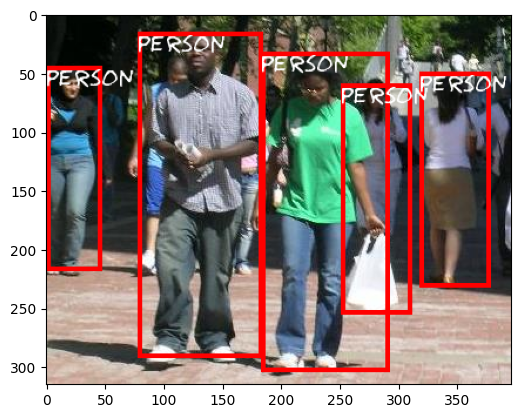

In [13]:
# TESTING AND VISUALIZATION

# visualization of bound-boxes associated with the objects (person)
import pdb
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image, ImageDraw, ImageFont
import random
font                = ImageFont.truetype("/usr/share/fonts/truetype/humor-sans/Humor-Sans.ttf", 20)


device              = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
# our dataset has two classes only - background and person
PENNFUDAN_INSTANCE_CATEGORY_NAMES = {0:'background', 1:'person'}
num_classes         = 2
model               = FasterRCNN(num_classes)
model.to(device)
model.load_state_dict(torch.load(root + '/output/faster_rcnn_model_finetuned.pth'))
model.eval()

test_sample_index = 0
end_offset        = 3

data_iter = iter(data_loader_test)
#for i, batch in enumerate(data_loader_test, start=start_offset):
while test_sample_index < len(data_loader_test):

    images, targets  = next(data_iter)
    print(f"Inference on test sample# {test_sample_index}")

    images            = list(image.to(device) for image in images)
    targets           = [{k: v for k, v in t.items()} for t in targets]
    predictions       = model(images)
    print(predictions)


    # visualize one of the images before running the inference
    SELECTED_IMAGE_INDEX = 0 # Change it to one of the values: 0, 1, 2, or 3. This will display the results for different images.
    img               = images[SELECTED_IMAGE_INDEX].cpu().numpy() # we have a batch of 4 images
    img               = img.transpose(1, 2, 0)
    #print(f"image shape is: {img.shape}")


    # draw the bounding boxes using PIL.ImageDraw, as we did in our in-class activity #1
    rgb_image         = 255*images[SELECTED_IMAGE_INDEX].cpu().numpy() # after reading as PIL.Image, the array entries get values that range between [0-1]
    rgb_image         = rgb_image.transpose(1, 2, 0)
    rgb_image         = rgb_image.astype(np.uint8)
    rgb_pil_img       = Image.fromarray(rgb_image)
    rgb_pil_img       = rgb_pil_img.convert('RGB')
    draw              = ImageDraw.Draw(rgb_pil_img)

    # draw rectangular bouding boxes on the image
    boxes             = predictions[SELECTED_IMAGE_INDEX]['boxes']
    labels            = predictions[SELECTED_IMAGE_INDEX]['labels']
    scores            = predictions[SELECTED_IMAGE_INDEX]['scores']

    font_size         = 70

    for i in range(len(boxes)):
        box         = boxes[i].detach().cpu().numpy()
        box         = box.astype(int)
        label_id    = labels[i].cpu()
        label_name  = PENNFUDAN_INSTANCE_CATEGORY_NAMES[label_id.item()]
        score       = scores[i]
        # print(f"bounding boxes: \n{box} for label={label_name}")

        # draw a rectangular bounding box on the image to display the detection result.
        if score > 0.5: # only display the detected objects with reliable predictions.

          draw.rectangle([box[0], box[1], box[2], box[3] ], outline="red", width=4)
          text_x_coord, text_y_coord = box[0], box[1]
          draw.text((text_x_coord, text_y_coord), label_name, font=font, fill=(255, 255, 255))



    # show the image
    if test_sample_index == end_offset:

      plt.imshow(np.asarray(rgb_pil_img))
      #pdb.set_trace()
      break

    # adjust the counter
    test_sample_index = test_sample_index + 1



#**Group task#3 (optional)**
### **You could fine-tune the Mask R-CNN model in the same way**
I am providing the `MaskRCNN` class with the important changes from our Faster R-CNN class. You may need this for your next assignment.


In [ ]:
import torch
import torch.nn as nn
from torchvision.models.detection import maskrcnn_resnet50_fpn          # import the pretrained model
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor  # you need to adjust the total number of output predictors (eg, i) pedestrian ii) backbround), as they might differ from those in pretrained dataset MS COCO which had 91 classes
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor

class MaskRCNN(nn.Module):

  def __init__(self, num_classes):
    super(MaskRCNN, self).__init__()

    self.model = maskrcnn_resnet50_fpn(pretrained=True)


    in_features = self.model.roi_heads.box_predictor.cls_score.in_features              # get the number of input features for the classifier

    self.model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)    # replace the pre-trained predictor head with a new one (both FastRCNN and FasterRCNN use the same predictor)

    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels            # get the number of input features for the classifier
    hidden_layer = 256
    self.model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask,           # replace the pre-trained predictor head with a new one (MaskRCNN head)
                                                       hidden_layer,
                                                       num_classes)
  def forward(self, x, target=None):
    output = self.model(x, target)
    return output




In [ ]:
# training loop
# ...
# ...
# ...

In [ ]:
# testing and visualization
# ...
# ...
# ...